Xây dựng rừng cây (Random Forest) trên dữ liệu Titanic lấy từ
https://www.kaggle.com/code/dmilla/introduction-to-decision-trees-titanic-dataset

# 1. Import thư viện & nạp dữ liệu

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [39]:
# Đọc dữ liệu từ file CSV
data = pd.read_csv("./data/train.csv")

# Xem 5 dòng đầu tiên
print(data.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [40]:
# Thông tin tổng quan về kiểu dữ liệu và số null
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [41]:
# Thống kê mô tả cho các cột số
print(data.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [42]:
# Đếm số lượng giá trị thiếu ở mỗi cột
print(data.isna().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# 2. Phân tích & loại bỏ features không liên quan

**Các cột loại bỏ:**
- PassengerId

    - Chỉ là ID định danh, không mang ý nghĩa dự đoán.

    - Không liên quan đến khả năng sống sót → loại.

- Name

    - Dữ liệu dạng text phức tạp.

    -Mô hình cơ bản không khai thác được thông tin tên.

    -Không góp phần cải thiện độ chính xác → loại.

- Ticket

    - Mã vé dạng text, không có quy luật rõ ràng.

    - Khó mã hóa, giá trị không nhất quán.

    - Ít liên quan đến sống/chết → loại.

- Cabin

    - Thiếu dữ liệu rất nhiều (>70%).

    - Không thể xử lý missing hiệu quả.

    - Nếu giữ lại dễ gây nhiễu → loại.

**Các cột giữ lại:**
- Pclass

    - Hạng vé (1, 2, 3).

    - Phản ánh địa vị/điều kiện sống → ảnh hưởng lớn đến khả năng sống sót.
 
- Sex
 
    - Giới tính nam/nữ.
    - 
    - Yếu tố quan trọng vì phụ nữ/ trẻ em được ưu tiên lên thuyền cứu hộ.
 
- Age
 
    - Tuổi của hành khách.
    
    - Yếu tố sinh học quan trọng (trẻ em dễ được cứu).
 
- SibSp
 
    - Số anh/chị/em hoặc vợ/chồng đi cùng.
    
    - Ảnh hưởng hành vi – người đi cùng có thể hỗ trợ hoặc gây chậm trễ khi di chuyển.
 
- Parch
 
    - Số bố/mẹ/con đi cùng.
    
    - Tương tự SibSp, phản ánh cấu trúc gia đình.
 
- Fare
 
    - Giá vé, liên quan đến điều kiện kinh tế.
    
    - Thường hành khách vé đắt (first class) sống sót nhiều hơn.
 
- Embarked
 
    - Cảng lên tàu (C, Q, S).
    
    - Thể hiện nơi xuất phát, có liên quan đến phân bố hạng vé.

Giải thích:

- Ta tạo data_model chỉ gồm các cột liên quan + cột mục tiêu Survived.

- Các cột bị bỏ: PassengerId, Name, Ticket, Cabin.

In [43]:
# Các cột sẽ giữ lại để dự đoán
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

# Xoá những cột không liên quan
data_model = data[features + ['Survived']].copy()

print(data_model.head())


   Pclass     Sex   Age  SibSp  Parch     Fare Embarked  Survived
0       3    male  22.0      1      0   7.2500        S         0
1       1  female  38.0      1      0  71.2833        C         1
2       3  female  26.0      0      0   7.9250        S         1
3       1  female  35.0      1      0  53.1000        S         1
4       3    male  35.0      0      0   8.0500        S         0


# 3. Tiền xử lý dữ liệu

## 3.1 Xử lý giá trị thiếu

Thường:

- Age bị thiếu → điền bằng median.

- Embarked có thể thiếu vài dòng → điền bằng mode (giá trị xuất hiện nhiều nhất).

In [44]:
# Điền tuổi thiếu bằng median
data_model['Age'] = data_model['Age'].fillna(data_model['Age'].median())

# Điền Embarked thiếu bằng mode
data_model['Embarked'] = data_model['Embarked'].fillna(data_model['Embarked'].mode()[0])

# Kiểm tra lại số missing values
print(data_model.isna().sum())


Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Survived    0
dtype: int64


## 3.2 Mã hoá biến phân loại (Sex, Embarked)

Ví dụ sau mã hoá, bạn có các cột như:

- Sex_male (0 = female, 1 = male)

- Embarked_Q, Embarked_S (so với Embarked_C bị drop)

In [45]:
# One-hot encoding cho các biến phân loại, bỏ 1 mức để tránh đa cộng tuyến (drop_first=True)
data_encoded = pd.get_dummies(data_model, columns=['Sex', 'Embarked'], drop_first=True)

print(data_encoded.head())
print(data_encoded.columns)


   Pclass   Age  SibSp  Parch     Fare  Survived  Sex_male  Embarked_Q  \
0       3  22.0      1      0   7.2500         0      True       False   
1       1  38.0      1      0  71.2833         1     False       False   
2       3  26.0      0      0   7.9250         1     False       False   
3       1  35.0      1      0  53.1000         1     False       False   
4       3  35.0      0      0   8.0500         0      True       False   

   Embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  
Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived', 'Sex_male',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')


# 4. Chia tập train/test và xây Random Forest

In [46]:
# Biến đầu vào X và nhãn y
X = data_encoded.drop('Survived', axis=1)
y = data_encoded['Survived']

# Chia train/test (vd: 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Kích thước tập train:", X_train.shape)
print("Kích thước tập test :", X_test.shape)


Kích thước tập train: (712, 8)
Kích thước tập test : (179, 8)


Huấn luyện RandomForestClassifier

Giải thích:

- n_estimators: số cây trong rừng

- max_depth: độ sâu tối đa mỗi cây

- min_samples_split: số mẫu tối thiểu để tách node

In [47]:

# Khởi tạo mô hình RandomForest
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1 # cho phép dùng nhiều core
)

# Lưới tham số để thử
param_grid_rf = {
    'n_estimators': [10, 50, 100, 200, 300, 500],
    'max_depth': [None, 4, 6, 8],
    'min_samples_split': [2, 5]
}

# GridSearchCV
rf_cv = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring='roc_auc',
    cv=4,
    refit=True,
    verbose=1,
    return_train_score=True
)

# Huấn luyện tìm tham số tốt nhất
rf_cv.fit(X_train, y_train)

print("Best params (Random Forest):", rf_cv.best_params_)
print("Best CV ROC-AUC:", rf_cv.best_score_)

Fitting 4 folds for each of 48 candidates, totalling 192 fits
Best params (Random Forest): {'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 500}
Best CV ROC-AUC: 0.8780323094444291


# 5. Tìm tham số tối ưu cho mô hình rừng cây và thực hiện train với tham số tối ưu đó

In [55]:
rf_params_ex = {'n_estimators':list(range(10,110,10))}

cv_rf_ex = GridSearchCV(
    rf,
    param_grid=rf_params_ex,
    scoring='roc_auc',
    n_jobs=None,
    refit=True,
    cv=4,
    verbose=1,
    error_score=np.nan,
    return_train_score=True
)

cv_rf_ex.fit(X_train, y_train)


Fitting 4 folds for each of 10 candidates, totalling 40 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'n_estimators': [10, 20, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,10


In [56]:
print("Best params:", cv_rf_ex.best_params_)
print("Best CV ROC-AUC:", cv_rf_ex.best_score_)

Best params: {'n_estimators': 10}
Best CV ROC-AUC: 0.8717647383227143


In [57]:
best_rf = cv_rf_ex.best_estimator_

# Dự đoán
y_pred = best_rf.predict(X_test)
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]


print("Test ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Test ROC-AUC: 0.8331357048748353
Test Accuracy: 0.8156424581005587
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



# 6. Vẽ biểu đồ đánh giá mô hình rừng cây với các tham số số cây có trong rừng khác nhau

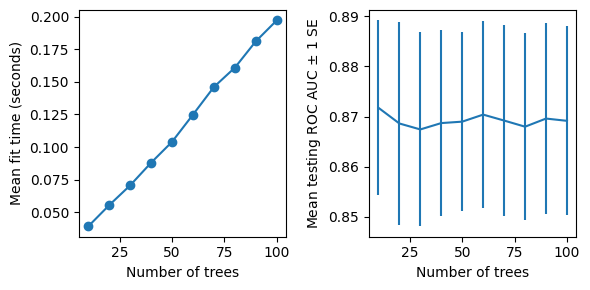

In [59]:
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
axs[0].plot(cv_rf_ex_results_df['param_n_estimators'],
cv_rf_ex_results_df['mean_fit_time'],
'-o')
axs[0].set_xlabel('Number of trees')
axs[0].set_ylabel('Mean fit time (seconds)')
axs[1].errorbar(cv_rf_ex_results_df['param_n_estimators'],
cv_rf_ex_results_df['mean_test_score'],
yerr=cv_rf_ex_results_df['std_test_score']/np.sqrt(4))
axs[1].set_xlabel('Number of trees')
axs[1].set_ylabel('Mean testing ROC AUC $\\pm$ 1 SE ')
plt.tight_layout()

# 7. Xem tham số tốt nhất của rừng cây, xem mức độ quan trọng của từng feature trong mô hình với tham số tốt nhất

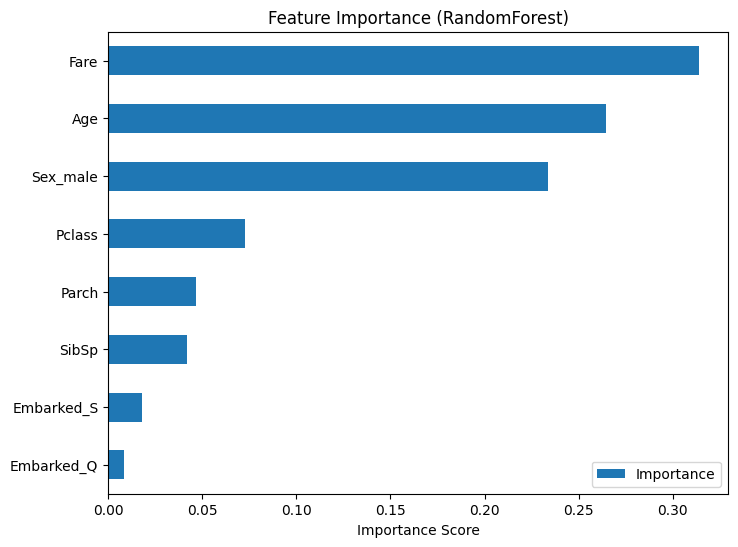

In [ ]:
feat_imp_df = pd.DataFrame({
    'Importance': best_rf.feature_importances_
}, index=X.columns)   # bỏ cột Survived

# Sắp xếp & vẽ biểu đồ
feat_imp_df.sort_values('Importance', ascending=True).plot.barh(figsize=(8,6))
plt.title("Feature Importance (RandomForest)")
plt.xlabel("Importance Score")
plt.show()

# Kết thúc